# 第二周作业：sklearn 中 KMeans 算法源码解析 - 2263185苏彦羽

本 notebook 基于 `scikit-learn 1.3.2`，对 `sklearn.cluster.KMeans` 的源码进行逐层解析。

目标：
1. 定位 KMeans 的源码文件；
2. 理清 `KMeans` 类的参数与属性；
3. 解析 `fit` 主流程：初始化 → 单次 K-means 迭代 → 多次运行择优；
4. 对比 Lloyd 与 Elkan 两种核心迭代；
5. 说明收敛判据、`predict`/`transform`/`score` 的实现；
6. 用一个小例子做完整流程验证。

> 环境：`vmunet`（Python 3.8 + scikit-learn 1.3.2），不做任何环境变动。

## 1. KMeans 算法基础

### 1.1 它解决什么问题

KMeans 是一种**无监督**的**划分型**聚类算法：给定 $n$ 个样本的特征矩阵 $X\in\mathbb{R}^{n\times d}$ 和簇数 $k$，把样本划分成 $k$ 个不相交的簇 $C_1,\dots,C_k$，使**簇内平方距离和（inertia / WSS）**最小：

$$\mathrm{inertia}=\sum_{i=1}^{k}\sum_{x\in C_i}\|x-\mu_i\|^2,\qquad \mu_i=\frac{1}{|C_i|}\sum_{x\in C_i}x$$

其中 $\mu_i$ 是簇 $C_i$ 的质心（簇内均值）。该优化问题本身是 **NP-hard**（参考 Aloise et al., 2009），所以 KMeans 只求**局部最优**。

### 1.2 经典 Lloyd 算法（EM 视角）

KMeans 可看作 EM 算法的特例（硬分配 + 均值更新），迭代两步直到收敛：

1. **E 步（Assignment 分配）**：每个样本分配到当前最近的质心

   $$\mathrm{label}(x)=\arg\min_c\|x-\mu_c\|^2$$

2. **M 步（Update 更新）**：每个质心更新为所属簇的（加权）均值

   $$\mu_c=\frac{\sum_{x\in C_c}w_x\,x}{\sum_{x\in C_c}w_x}$$

两步都会让 inertia **单调不增**（每步都是当前分配下的最优解），所以保证收敛到一个不动点（局部最优）。

### 1.3 算法流程示意

```
初始化 k 个质心 μ₁..μ_k     ← random / k-means++ / 用户给定
┌──────────────────────────┐
│  E 步：把每个 x 分给最近 μ │  ← assign
│  M 步：μ ← 簇内加权均值     │  ← update
│  收敛？(标签不变 / 位移≤tol)│
└─────────────┬────────────┘
              │ 否
              └─→ 回到 E 步
              是
              ↓
         输出 labels / centers / inertia
```

### 1.4 关键性质与常见坑

- **k 必须事先指定**：KMeans 不会自动确定簇数；常用 elbow（肘部法）、silhouette（轮廓系数）、gap statistic 选 k。
- **对初始化敏感**：不同 init 可能收敛到不同局部最优 → sklearn 默认 `n_init=10` 重启取最优（1.4 起 `'auto'`：对 k-means++ 退化为 1 次，因为 k-means++ 本身已较稳）。
- **k-means++ 初始化**（D. Arthur & S. Vassilvitskii, 2007）：按 $D(x)^2$ 加权采样，理论上把期望 inertia 控制在 $O(\log k)$ 倍最优内，显著降低劣解概率。
- **假设凸球形簇**：基于欧氏距离，对非凸形状（如两个同心圆、月牙形）效果差；此类数据可用 DBSCAN、谱聚类、Mean-Shift。
- **对尺度敏感**：特征量纲不同会让大尺度特征主导距离 → 用之前请 `StandardScaler` 标准化。
- **复杂度**：平均 $O(k\cdot n\cdot T)$，$T$ 为迭代轮数；最坏 $O(n^{k+2/p})$。
- **inertia 是单调下降指标**：$k$ 越大 inertia 越小，**不能**直接用它选 k（会偏好大 k）。
- **离群点敏感**：一个远离主体的点会把质心拉偏；可用 `MiniBatchKMeans` 或 K-Medoids 缓解。

> 下面从源码层面，逐层看 scikit-learn 1.3.2 是如何实现上述每一步的。


## 2. 定位源码文件

KMeans 的 Python 实现位于 `sklearn/cluster/_kmeans.py`。核心的迭代计算（Lloyd/Elkan 的单步）则被拆分到 Cython 扩展模块里，以提升性能：

- `sklearn/cluster/_k_means_lloyd.pyx` → `lloyd_iter_chunked_dense/sparse`
- `sklearn/cluster/_k_means_elkan.pyx`  → `elkan_iter_chunked_dense/sparse`、`init_bounds_dense/sparse`
- `sklearn/cluster/_k_means_minibatch.pyx` → MiniBatchKMeans 使用
- `sklearn/cluster/_k_means_common.pyx`  → `_inertia_dense/sparse`、`_is_same_clustering`、`CHUNK_SIZE`

In [1]:
import sklearn, os
print('sklearn version:', sklearn.__version__)
print('sklearn path   :', sklearn.__file__)

kmeans_py = os.path.join(os.path.dirname(sklearn.__file__), 'cluster', '_kmeans.py')
print('_kmeans.py     :', kmeans_py)
print('exists         :', os.path.exists(kmeans_py))

import inspect
from sklearn.cluster import KMeans
print('KMeans defined at:', inspect.getsourcefile(KMeans))

sklearn version: 1.3.2
sklearn path   : /root/MSA/ENTER/envs/vmunet/lib/python3.8/site-packages/sklearn/__init__.py
_kmeans.py     : /root/MSA/ENTER/envs/vmunet/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py
exists         : True
KMeans defined at: /root/MSA/ENTER/envs/vmunet/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py


## 3. `KMeans` 类的参数与属性

`KMeans` 继承自 `_BaseKMeans`（同一文件 825 行起），自身只额外增加了 `copy_x` 与 `algorithm` 两个参数。

**构造函数签名**（`_kmeans.py` L1389–L1401）：

```python
def __init__(
    self,
    n_clusters=8,
    *,
    init="k-means++",
    n_init="warn",      # 1.4 起默认 'auto'：'k-means++'/array ⇒ 1，'random'/callable ⇒ 10
    max_iter=300,
    tol=1e-4,
    verbose=0,
    random_state=None,
    copy_x=True,
    algorithm="lloyd",  # {'lloyd','elkan','auto','full'}，'auto'/'full' 已废弃
):
```

**关键属性**（`fit` 后产生）：
- `cluster_centers_`：质心，shape `(n_clusters, n_features)`
- `labels_`：每个样本所属簇索引，shape `(n_samples,)`
- `inertia_`：样本到最近质心的平方距离之和（带 `sample_weight` 加权）
- `n_iter_`：单次最佳运行的迭代次数
- `n_features_in_` / `feature_names_in_`：输入特征数与名称

**复杂度说明**（docstring L1345–L1355）：平均 `O(k·n·T)`，最坏 `O(n^(k+2/p))`，实践上很快但容易陷入局部最优，因此多次重启很有意义。

In [2]:
import inspect
from sklearn.cluster._kmeans import KMeans, _BaseKMeans

print('--- KMeans.__init__ signature ---') # 查看构造函数与参数约束
print(inspect.signature(KMeans.__init__))
print('\n--- KMeans._parameter_constraints ---')
for k, v in KMeans._parameter_constraints.items():
    print(f'{k:14s}: {v}')
print('\n--- _BaseKMeans._parameter_constraints ---')
for k, v in _BaseKMeans._parameter_constraints.items():
    print(f'{k:14s}: {v}')

--- KMeans.__init__ signature ---
(self, n_clusters=8, *, init='k-means++', n_init='warn', max_iter=300, tol=0.0001, verbose=0, random_state=None, copy_x=True, algorithm='lloyd')

--- KMeans._parameter_constraints ---
n_clusters    : [<sklearn.utils._param_validation.Interval object at 0x7042bab51220>]
init          : [<sklearn.utils._param_validation.StrOptions object at 0x7042bab51250>, <built-in function callable>, 'array-like']
n_init        : [<sklearn.utils._param_validation.StrOptions object at 0x7042bab512e0>, <sklearn.utils._param_validation.Hidden object at 0x7042bab513a0>, <sklearn.utils._param_validation.Interval object at 0x7042bab51400>]
max_iter      : [<sklearn.utils._param_validation.Interval object at 0x7042bab51430>]
tol           : [<sklearn.utils._param_validation.Interval object at 0x7042bab51490>]
verbose       : ['verbose']
random_state  : ['random_state']
copy_x        : ['boolean']
algorithm     : [<sklearn.utils._param_validation.StrOptions object at 0x7042ba

## 4. `fit` 主流程（`_kmeans.py` L1446–L1573）

`fit` 是 KMeans 的核心入口，整体可分为 **5 个阶段**：

1. **数据校验**（L1474–L1481）：`_validate_data` 将 `X` 转成 C-contiguous 的 float32/float64；稀疏矩阵必须 CSR；`copy_x=False` 时原地修改。
2. **参数校验与算法选择**（L1483–L1487 `_check_params_vs_input`）：处理 `n_init='auto'/'warn'`；`auto/full` 警告并退化为 `lloyd`；`elkan` 在 `n_clusters==1` 时退化为 `lloyd`。
3. **数据中心化**（L1497–L1506）：非稀疏时减去 `X.mean(axis=0)`，提高距离计算数值精度；同时预计算每个样本的平方范数 `x_squared_norms`（用于 `||x-c||² = ||x||² - 2·x·c + ||c||²` 的快速展开）。
4. **多次重启择优**（L1516–L1552）：循环 `_n_init` 次，每次先 `_init_centroids` 得到初始质心，再调用 `_kmeans_single_elkan` 或 `_kmeans_single_lloyd`，保留 `inertia` 最小且聚类结果与当前最优不同的那次（避免因置换标签造成的“假性更优”）。
5. **回写属性**（L1553–L1572）：把质心加回 `X_mean`；若实际簇数 < n_clusters 给出 `ConvergenceWarning`；最后保存 `cluster_centers_`、`labels_`、`inertia_`、`n_iter_`。

关键细节：**第 4 步的“择优”条件**用的是 `_is_same_clustering(labels, best_labels, n_clusters)`（在 `_k_means_common.pyx`），它会比较两个标签集合在「按簇重命名」后是否一致，从而避免不同 init 但相同聚类划分的结果被舍去。

In [3]:
import inspect
from sklearn.cluster._kmeans import KMeans
src = inspect.getsource(KMeans.fit)
print(src) # 打印 fit 方法的源码（截取关键片段）

    @_fit_context(prefer_skip_nested_validation=True)
    def fit(self, X, y=None, sample_weight=None):
        """Compute k-means clustering.

        Parameters
        ----------
        X : {array-like, sparse matrix} of shape (n_samples, n_features)
            Training instances to cluster. It must be noted that the data
            will be converted to C ordering, which will cause a memory
            copy if the given data is not C-contiguous.
            If a sparse matrix is passed, a copy will be made if it's not in
            CSR format.

        y : Ignored
            Not used, present here for API consistency by convention.

        sample_weight : array-like of shape (n_samples,), default=None
            The weights for each observation in X. If None, all observations
            are assigned equal weight. `sample_weight` is not used during
            initialization if `init` is a callable or a user provided array.

            .. versionadded:: 0.20

        Returns

## 5. 质心初始化 `_init_centroids`（L960–L1044）

依据 `init` 的类型分四种：

| `init` 取值 | 行为 |
|---|---|
| `'k-means++'` | 调用 `_kmeans_plusplus`，按 D² 概率采样 |
| `'random'`   | 按样本权重无放回抽样 n_clusters 个点作为质心 |
| array-like   | 直接作为初始质心（会校验 shape） |
| callable     | `init(X, n_clusters, random_state=...)` 返回质心 |

> 注：`init_size` 是 **`MiniBatchKMeans`** 的参数（用于在大数据上抽样加速初始化），`KMeans` 类本身**不暴露**此参数——它直接用全部 `X` 做初始化。原文将 `init_size` 列入 `KMeans` 的初始化流程有误，特此更正。

### 5.1 k-means++ 的实现 `_kmeans_plusplus`（L178–L276）

scikit-learn 使用的是 **greedy k-means++**（D. Arthur & S. Vassilvitskii, 2007）：

1. 第一个中心从样本中按 `sample_weight` 加权随机抽一个；
2. 对剩余 `n_clusters-1` 个中心，每次：
   - `n_local_trials = 2 + int(log(n_clusters))`（默认）个候选；
   - 每个候选按 `D(x)²` 的概率（与到最近已选中心的平方距离成正比）采样；
   - 计算每个候选加入后的总势 `candidate_pot = Σ w·min(D(x)², D_to_candidate(x)²)`；
   - 贪心选择 `argmin(candidate_pot)` 作为新的中心。

这比 vanilla k-means++（每次只抽一个）能进一步降低最终 inertia，期望复杂度为 `O(log k)`，但常数更大。

In [4]:
from sklearn.cluster._kmeans import _kmeans_plusplus, kmeans_plusplus
import inspect
print('--- kmeans_plusplus (public, 含 validate_params) ---')
print(inspect.getsource(kmeans_plusplus)[:600])
print('\n--- _kmeans_plusplus (内部实现) ---')
print(inspect.getsource(_kmeans_plusplus))

--- kmeans_plusplus (public, 含 validate_params) ---
@validate_params(
    {
        "X": ["array-like", "sparse matrix"],
        "n_clusters": [Interval(Integral, 1, None, closed="left")],
        "sample_weight": ["array-like", None],
        "x_squared_norms": ["array-like", None],
        "random_state": ["random_state"],
        "n_local_trials": [Interval(Integral, 1, None, closed="left"), None],
    },
    prefer_skip_nested_validation=True,
)
def kmeans_plusplus(
    X,
    n_clusters,
    *,
    sample_weight=None,
    x_squared_norms=None,
    random_state=None,
    n_local_trials=None,
):
    """Init n_clusters seeds according to k-m

--- _kmeans_plusplus (内部实现) ---
def _kmeans_plusplus(
    X, n_clusters, x_squared_norms, sample_weight, random_state, n_local_trials=None
):
    """Computational component for initialization of n_clusters by
    k-means++. Prior validation of data is assumed.

    Parameters
    ----------
    X : {ndarray, sparse matrix} of shape (n_samples, 

## 6. Lloyd 算法核心 `_kmeans_single_lloyd`（L611–L742）

经典 EM 迭代，每轮做：

1. **E 步 + M 步合并到一次 Cython 调用** `lloyd_iter_chunked_dense/sparse(...)`：
   - 把每个样本分配到最近的当前质心（更新 `labels`、`weight_in_clusters`）；
   - 用簇内（加权）均值更新 `centers_new`；
   - 同时记录每个质心的位移 `center_shift = centers_new - centers`。
2. **交换缓冲区** `centers, centers_new = centers_new, centers`（in-place 节省内存）。
3. **收敛判定**：
   - 严格收敛：`np.array_equal(labels, labels_old)`（标签不再变化）⇒ 立即 break；
   - 容差收敛：`center_shift_tot = Σ center_shift² ≤ tol` ⇒ break。
4. **若非严格收敛**，最后再做一次 E 步（`update_centers=False`），保证 `labels_` 与 `cluster_centers_` 一致（注释 L726–L738）。
5. 末尾计算 `inertia = _inertia_dense/sparse(...)` 返回。

**关于 `tol`**：注意 `_tolerance(X, tol)`（L283–L291）把用户给的 `tol` 转成「与数据尺度相关」的实际阈值：`tol_actual = mean(var(X, axis=0)) * tol`。这意味着 `tol` 是相对量纲，跟特征的方差挂钩，而不是绝对距离。

**关于线程**：`with threadpool_limits(limits=1, user_api="blas")` 把 BLAS 的二级并行限制为 1，避免与 OpenMP（一级并行，sample-wise）争抢造成 oversubscription。

In [5]:
from sklearn.cluster._kmeans import _kmeans_single_lloyd, _tolerance
import inspect
print('--- _tolerance ---')
print(inspect.getsource(_tolerance))
print('\n--- _kmeans_single_lloyd ---')
print(inspect.getsource(_kmeans_single_lloyd))

--- _tolerance ---
def _tolerance(X, tol):
    """Return a tolerance which is dependent on the dataset."""
    if tol == 0:
        return 0
    if sp.issparse(X):
        variances = mean_variance_axis(X, axis=0)[1]
    else:
        variances = np.var(X, axis=0)
    return np.mean(variances) * tol


--- _kmeans_single_lloyd ---
def _kmeans_single_lloyd(
    X,
    sample_weight,
    centers_init,
    max_iter=300,
    verbose=False,
    tol=1e-4,
    n_threads=1,
):
    """A single run of k-means lloyd, assumes preparation completed prior.

    Parameters
    ----------
    X : {ndarray, sparse matrix} of shape (n_samples, n_features)
        The observations to cluster. If sparse matrix, must be in CSR format.

    sample_weight : ndarray of shape (n_samples,)
        The weights for each observation in X.

    centers_init : ndarray of shape (n_clusters, n_features)
        The initial centers.

    max_iter : int, default=300
        Maximum number of iterations of the k-means alg

## 7. Elkan 算法核心 `_kmeans_single_elkan`（L446–L608）

Elkan 利用**三角不等式**减少距离计算次数，对低维、簇结构明显的数据更快，但需要额外的 `(n_samples, n_clusters)` 内存。

**关键数据结构**：
- `center_half_distances`：质心两两距离的一半，shape `(k, k)`；
- `distance_next_center`：每个质心到「最近的其他质心」的距离的一半（`np.partition(..., kth=1)[1]`）；
- `upper_bounds[i]`：样本 i 到其当前最近质心距离的**上界**；
- `lower_bounds[i, c]`：样本 i 到质心 c 距离的**下界**。

**初始化**：`init_bounds_dense/sparse(...)` 用真实距离初始化 `upper_bounds`/`lower_bounds`/`labels`。

**每轮 `elkan_iter_chunked_*`**：
- 利用三角不等式跳过大部分距离计算：
  - 若 `upper_bounds[i] ≤ lower_bounds[i, c]`，则 c 不可能比当前最近更近，跳过；
  - 若 `upper_bounds[i] ≤ 0.5 * dist(c, c')`（即 `distance_next_center[c]`），则 c 仍是最优，跳过；
- 必要时才真正算一次 `||x-c||²`，并更新上/下界；
- M 步：用簇内加权均值更新质心；
- 用 `center_shift` 修正所有 bound：`upper_bounds[i] += shift[c]`、`lower_bounds[i, c] -= shift[c]` 等（保证下一轮的界仍然有效）。

**收敛判据与 Lloyd 完全一致**（严格收敛 + 容差收敛），并在非严格收敛时补做一次 E 步。

In [6]:
from sklearn.cluster._kmeans import _kmeans_single_elkan
import inspect
print(inspect.getsource(_kmeans_single_elkan))

def _kmeans_single_elkan(
    X,
    sample_weight,
    centers_init,
    max_iter=300,
    verbose=False,
    tol=1e-4,
    n_threads=1,
):
    """A single run of k-means elkan, assumes preparation completed prior.

    Parameters
    ----------
    X : {ndarray, sparse matrix} of shape (n_samples, n_features)
        The observations to cluster. If sparse matrix, must be in CSR format.

    sample_weight : array-like of shape (n_samples,)
        The weights for each observation in X.

    centers_init : ndarray of shape (n_clusters, n_features)
        The initial centers.

    max_iter : int, default=300
        Maximum number of iterations of the k-means algorithm to run.

    verbose : bool, default=False
        Verbosity mode.

    tol : float, default=1e-4
        Relative tolerance with regards to Frobenius norm of the difference
        in the cluster centers of two consecutive iterations to declare
        convergence.
        It's not advised to set `tol=0` since convergen

## 8. 收敛与择优细节

回到 `fit` 的循环（L1516–L1552），单次运行的输出 `(labels, inertia, centers, n_iter_)` 被接受为新最优的条件是：

```python
if best_inertia is None or (
    inertia < best_inertia
    and not _is_same_clustering(labels, best_labels, self.n_clusters)
):
```

即 **「inertia 严格更小」** 且 **「聚类划分确实不同」** 才替换。这样能避免不同 init 命中同一个局部最优（标签被置换）时白白覆盖 `best_n_iter` 等。

In [7]:
# _is_same_clustering 来自 Cython 模块 _k_means_common，无法用 inspect 看源码，但可看 docstring/导入
from sklearn.cluster._k_means_common import _is_same_clustering, _inertia_dense, _inertia_sparse, CHUNK_SIZE
print('_is_same_clustering:', _is_same_clustering.__doc__ or '(no docstring in compiled module)')
print('CHUNK_SIZE        :', CHUNK_SIZE)
print('_inertia_dense    :', _inertia_dense.__doc__ or '(no docstring in compiled module)')

# 用 _is_same_clustering 做个小验证：置换标签应被判为同一聚类
# 注意：该 Cython 函数要求 labels 为 int32，否则会报 Buffer dtype mismatch
import numpy as np
a = np.array([0, 0, 1, 1, 2, 2], dtype=np.int32)
b = np.array([2, 2, 0, 0, 1, 1], dtype=np.int32)  # 0->2, 1->0, 2->1 的置换
print('same clustering (permuted):', _is_same_clustering(a, b, 3))
c = np.array([0, 1, 0, 1, 2, 2], dtype=np.int32)  # 真正不同的划分
print('same clustering (diff)    :', _is_same_clustering(a, c, 3))

_is_same_clustering: Check if two arrays of labels are the same up to a permutation of the labels
CHUNK_SIZE        : 256
_inertia_dense    : Compute inertia for dense input data

    Sum of squared distance between each sample and its assigned center.

    If single_label is >= 0, the inertia is computed only for that label.
    
same clustering (permuted): True
same clustering (diff)    : False


## 9. `predict` / `transform` / `score`（L1071–L1200）

- **`predict(X)`**（L1071–L1119）：先 `check_is_fitted`，再 `_check_test_data` 校验输入；调用 `_labels_inertia_threadpool_limit`，返回 `labels_`（不更新质心）。`sample_weight` 参数自 1.3 起被弃用，仅触发 `FutureWarning`。
- **`transform(X)`**（L1145–L1170）：返回样本到每个质心的距离，shape `(n_samples, n_clusters)`；内部走 `_transform`，本质是 `euclidean_distances(X, cluster_centers_)`。
- **`score(X)`**（L1171–L1200）：返回 **负的 inertia**（越大越好，符合 sklearn「score 越大越好」的惯例）。

In [8]:
from sklearn.cluster._kmeans import _labels_inertia, _labels_inertia_threadpool_limit
import inspect
print('--- _labels_inertia (E 步) ---')
print(inspect.getsource(_labels_inertia))

--- _labels_inertia (E 步) ---
def _labels_inertia(X, sample_weight, centers, n_threads=1, return_inertia=True):
    """E step of the K-means EM algorithm.

    Compute the labels and the inertia of the given samples and centers.

    Parameters
    ----------
    X : {ndarray, sparse matrix} of shape (n_samples, n_features)
        The input samples to assign to the labels. If sparse matrix, must
        be in CSR format.

    sample_weight : ndarray of shape (n_samples,)
        The weights for each observation in X.

    x_squared_norms : ndarray of shape (n_samples,)
        Precomputed squared euclidean norm of each data point, to speed up
        computations.

    centers : ndarray of shape (n_clusters, n_features)
        The cluster centers.

    n_threads : int, default=1
        The number of OpenMP threads to use for the computation. Parallelism is
        sample-wise on the main cython loop which assigns each sample to its
        closest center.

    return_inertia : bool,

## 10. `k_means` 顶层函数（L302–L445）

除了面向对象的 `KMeans` 类，sklearn 还提供等价的函数式入口 `sklearn.cluster.k_means(...)`，返回 `(best_labels, best_centers, best_inertia, best_n_iter)`。它内部把构造 + `fit` 串起来，方便一次性调用。

In [9]:
from sklearn.cluster._kmeans import k_means
import inspect
print(inspect.signature(k_means))
# 只打印 docstring 的开头，避免太长
print((k_means.__doc__ or '')[:800])

(X, n_clusters, *, sample_weight=None, init='k-means++', n_init='warn', max_iter=300, verbose=False, tol=0.0001, random_state=None, copy_x=True, algorithm='lloyd', return_n_iter=False)
Perform K-means clustering algorithm.

    Read more in the :ref:`User Guide <k_means>`.

    Parameters
    ----------
    X : {array-like, sparse matrix} of shape (n_samples, n_features)
        The observations to cluster. It must be noted that the data
        will be converted to C ordering, which will cause a memory copy
        if the given data is not C-contiguous.

    n_clusters : int
        The number of clusters to form as well as the number of
        centroids to generate.

    sample_weight : array-like of shape (n_samples,), default=None
        The weights for each observation in `X`. If `None`, all observations
        are assigned equal weight. `sample_weight` is not used during
        initialization if `init` is a callable or a user provided array.

    init : {'k-mea


## 11. 端到端例子
用一个 2D 的人造数据集，对比 `lloyd` 与 `elkan` 两种算法的输出一致性，并打印收敛信息。

In [10]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import v_measure_score

X, y_true = make_blobs(n_samples=1000, centers=4, cluster_std=0.6,
                       random_state=0, n_features=2)

km_lloyd = KMeans(n_clusters=4, init='k-means++', n_init=10,
                  max_iter=300, tol=1e-4, algorithm='lloyd',
                  random_state=0)
km_elkan = KMeans(n_clusters=4, init='k-means++', n_init=10,
                  max_iter=300, tol=1e-4, algorithm='elkan',
                  random_state=0)

km_lloyd.fit(X)
km_elkan.fit(X)

print('Lloyd : inertia=%.4f, n_iter=%d' % (km_lloyd.inertia_, km_lloyd.n_iter_))
print('Elkan : inertia=%.4f, n_iter=%d' % (km_elkan.inertia_, km_elkan.n_iter_))
print('centers close :', np.allclose(np.sort(km_lloyd.cluster_centers_, axis=0),
                                     np.sort(km_elkan.cluster_centers_, axis=0)))
print('V-measure Lloyd :', round(v_measure_score(y_true, km_lloyd.labels_), 4))
print('V-measure Elkan :', round(v_measure_score(y_true, km_elkan.labels_), 4))

Lloyd : inertia=680.1708, n_iter=3
Elkan : inertia=680.1708, n_iter=3
centers close : True
V-measure Lloyd : 0.9869
V-measure Elkan : 0.9869


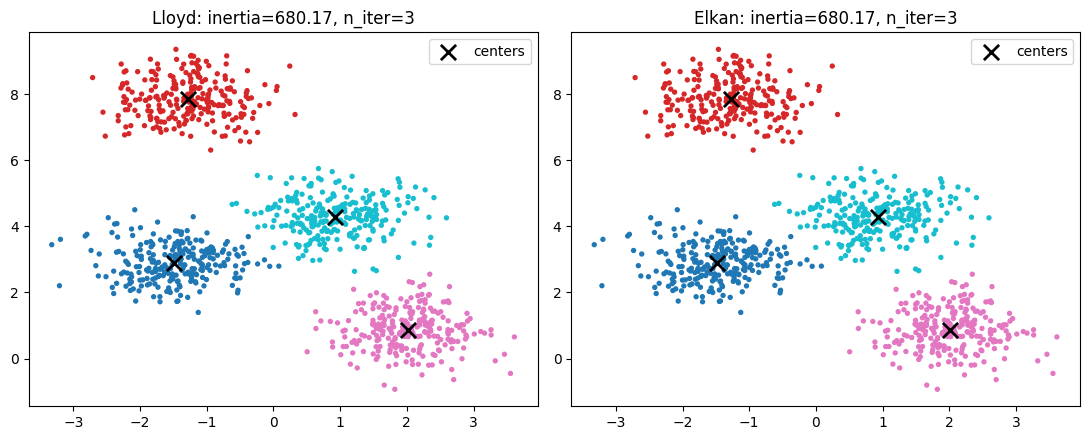

In [11]:
# 可视化聚类结果
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, km, name in zip(axes, [km_lloyd, km_elkan], ['Lloyd', 'Elkan']):
    ax.scatter(X[:, 0], X[:, 1], c=km.labels_, s=8, cmap='tab10')
    ax.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
               marker='x', s=120, linewidths=2, color='black', label='centers')
    ax.set_title(f'{name}: inertia={km.inertia_:.2f}, n_iter={km.n_iter_}')
    ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

Lloyd steps: 4 | Elkan steps: 4
same final centers: True
same trajectory: True


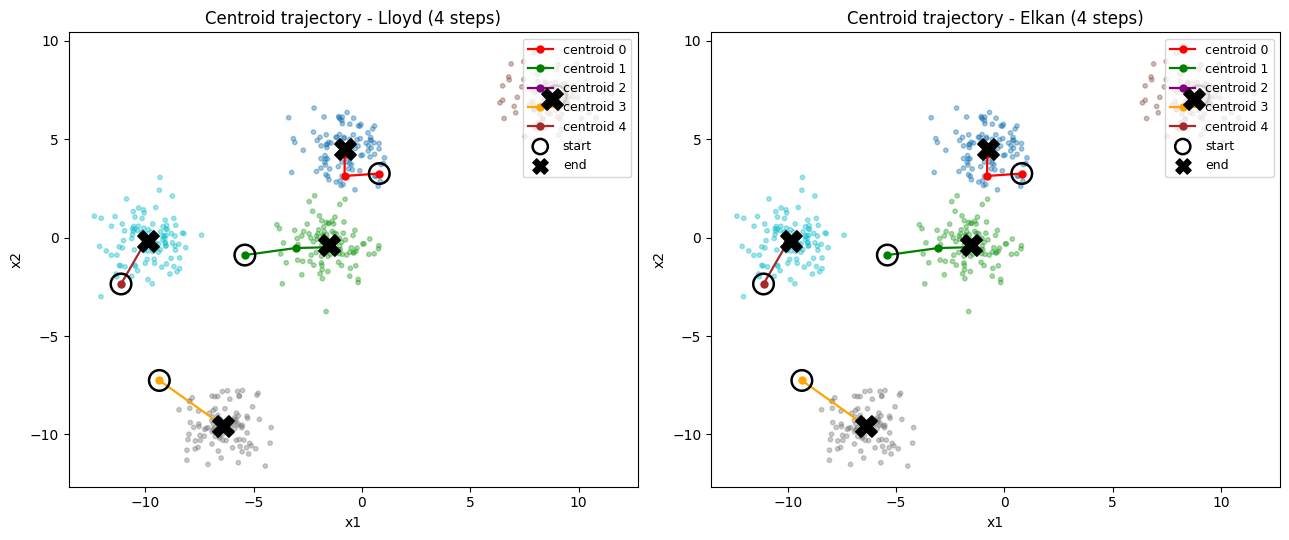

In [12]:
# 中心轨迹图：分别用 sklearn 的 Lloyd 与 Elkan 各跑一遍，记录质心每轮位置
# 做法：max_iter=1 逐轮 fit，把上一轮 cluster_centers_ 作为下一轮 init
# 初始化用 bounding-box 均匀随机点（非 k-means++），质心需多步迁移轨迹才好看
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

X_tr, _ = make_blobs(n_samples=500, centers=5, cluster_std=1.0,
                     random_state=11, n_features=2)
K = 5
rng = np.random.RandomState(3)
lo, hi = X_tr.min(axis=0), X_tr.max(axis=0)
init_c = rng.uniform(lo, hi, size=(K, 2))          # 均匀随机初始化

def sklearn_trajectory(algo, X, init_centers, n_iter=30):
    """逐轮 fit(max_iter=1) 记录质心轨迹，调用真实 sklearn 的 Lloyd/Elkan。"""
    centers = init_centers.copy()
    traj = [centers.copy()]
    for _ in range(n_iter):
        km = KMeans(n_clusters=len(init_centers), init=centers, n_init=1,
                    max_iter=1, tol=0, algorithm=algo, random_state=0)
        km.fit(X)
        new = km.cluster_centers_
        if np.allclose(new, centers):
            break
        centers = new
        traj.append(centers.copy())
    return centers, np.array(traj)

fin_lloyd, traj_lloyd = sklearn_trajectory('lloyd', X_tr, init_c)
fin_elkan, traj_elkan = sklearn_trajectory('elkan', X_tr, init_c)

print('Lloyd steps:', len(traj_lloyd) - 1, '| Elkan steps:', len(traj_elkan) - 1)
print('same final centers:', np.allclose(np.sort(fin_lloyd, axis=0),
                                          np.sort(fin_elkan, axis=0)))
print('same trajectory:', np.allclose(traj_lloyd, traj_elkan))

def labels_to(centers):
    d = np.linalg.norm(X_tr[:, None, :] - centers[None, :, :], axis=2)
    return d.argmin(axis=1)

colors = ['red', 'green', 'purple', 'orange', 'brown']
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, traj, fin, name in [(axes[0], traj_lloyd, fin_lloyd, 'Lloyd'),
                             (axes[1], traj_elkan, fin_elkan, 'Elkan')]:
    ax.scatter(X_tr[:, 0], X_tr[:, 1], c=labels_to(fin), s=10,
               cmap='tab10', alpha=0.4)
    for c in range(traj.shape[1]):
        path = traj[:, c, :]
        ax.plot(path[:, 0], path[:, 1], '-o', color=colors[c % len(colors)],
                markersize=5, linewidth=1.6, label=f'centroid {c}')
        # start: open circle
        ax.scatter(path[0, 0], path[0, 1], marker='o', s=220,
                   edgecolor='black', facecolor='none', linewidth=1.8, zorder=5)
        # end: black X
        ax.scatter(path[-1, 0], path[-1, 1], marker='X', s=240,
                   color='black', zorder=6)
    # ASCII legend entries for start/end markers
    ax.scatter([], [], marker='o', s=120, edgecolor='black',
               facecolor='none', linewidth=1.8, label='start')
    ax.scatter([], [], marker='X', s=120, color='black', label='end')
    ax.set_title(f'Centroid trajectory - {name} ({len(traj)-1} steps)')
    ax.set_xlabel('x1'); ax.set_ylabel('x2')
    ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()


## 12. 用 verbose=True 观察迭代过程

`fit` 内部 `if self.verbose: print('Initialization complete')`，而单次迭代函数也会打印每轮 inertia 与收敛信息（见 L701–L710、L563–L565）。把 `verbose=1` 打开即可看到。

In [13]:
import sys
km_v = KMeans(n_clusters=4, init='random', n_init=3, max_iter=50,
              tol=1e-4, algorithm='lloyd', random_state=0, verbose=1)
km_v.fit(X)
print('\nfinal inertia:', km_v.inertia_, '| n_iter_:', km_v.n_iter_)

Initialization complete
Iteration 0, inertia 1162.2860634859578.
Iteration 1, inertia 680.4586086030592.
Iteration 2, inertia 680.1708340947262.
Converged at iteration 2: strict convergence.
Initialization complete
Iteration 0, inertia 3981.9042487481797.
Iteration 1, inertia 842.4938314792107.
Iteration 2, inertia 680.2079819659768.
Converged at iteration 2: center shift 0.0001484036577055154 within tolerance 0.00046699124651711465.
Initialization complete
Iteration 0, inertia 3043.570303482225.
Iteration 1, inertia 1680.082790831333.
Iteration 2, inertia 1594.0311859836713.
Iteration 3, inertia 1592.6225060329928.
Iteration 4, inertia 1592.070862463306.
Iteration 5, inertia 1591.760037538312.
Iteration 6, inertia 1591.5498546788854.
Iteration 7, inertia 1591.279748291317.
Iteration 8, inertia 1591.1870807025261.
Converged at iteration 8: center shift 7.92643742817536e-05 within tolerance 0.00046699124651711465.

final inertia: 680.170834094726 | n_iter_: 3


## 13. 流程小结

```
KMeans.fit(X)
├─ _validate_data(X)              # 类型/C-order/CSR/数值类型
├─ _check_params_vs_input(X)      # n_init='auto'/'warn'、algorithm 退化处理
├─ check_random_state / _check_sample_weight / _openmp_effective_n_threads
├─ 减去 X.mean(axis=0)             # 非稀疏时，提高精度
├─ row_norms(X, squared=True)     # 预算 ||x||²
├─ for i in range(_n_init):        # 多次重启
│   ├─ _init_centroids             # k-means++ / random / array / callable
│   ├─ kmeans_single =
│   │   ├─ _kmeans_single_elkan   # 三角不等式 + upper/lower bounds
│   │   └─ _kmeans_single_lloyd   # 经典 EM：assign + update
│   └─ 若 inertia 更小且划分不同 ⇒ 更新 best_*
├─ best_centers += X_mean         # 把中心加回
└─ 写回 cluster_centers_ / labels_ / inertia_ / n_iter_
```

**要点回顾**：
- **算法主体**：Lloyd（EM）与 Elkan（三角不等式加速），两者收敛判据一致；
- **初始化**：greedy k-means++（默认）显著降低陷入劣解的概率；
- **多次重启**：`n_init` 次择优，按 inertia 最小且划分不同筛选；
- **数值技巧**：数据中心化 + 预算 `||x||²` + `||x-c||² = ||x||²-2x·c+||c||²`；BLAS 二级并行限制为 1 以避免线程争抢；
- **性能关键路径**：单步 assign+update 落在 Cython（`_k_means_lloyd.pyx` / `_k_means_elkan.pyx`），并按 `CHUNK_SIZE` 分块以利于 cache；
- **`tol` 是相对量纲**：实际阈值 = `mean(var(X)) * tol`，与数据尺度挂钩。